In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import poisson

### Poisson分布の形状

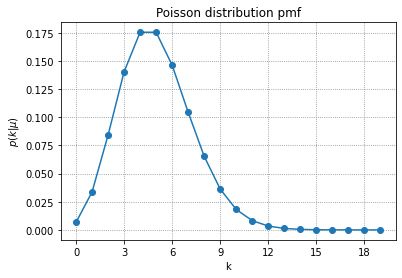

In [2]:
# ----- you can set values below -----
mu = 5
# ------------------------------------

k = np.arange(0,20)
y = poisson.pmf(k, mu)

# X軸の数字が必ず整数になるようにする
import matplotlib.ticker as ticker
plt.gca().get_xaxis().set_major_locator(ticker.MaxNLocator(integer=True))
plt.plot(k,y,marker='o')
plt.xlabel('k')
plt.ylabel('$p(k|\mu)$')
plt.title('Poisson distribution pmf')
plt.grid(color='gray',linestyle=':');

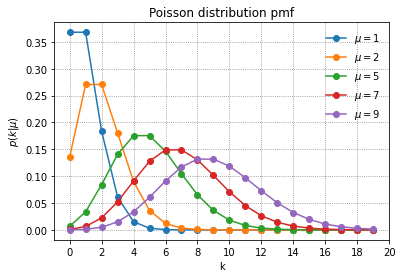

In [3]:
k = np.arange(0,20)
mus = [1, 2, 5, 7, 9]
y = np.zeros((len(mus),k.size))

for i, mu in enumerate(mus):
    y = poisson.pmf(k, mu)
    plt.plot(k,y,marker='o', label='$\mu=%d$' % mus[i])

plt.xlabel('k')
plt.ylabel('$p(k|\mu)$')
plt.title('Poisson distribution pmf')
plt.xticks(np.arange(0, 21, 2))
plt.grid(color='gray',linestyle=':')
plt.legend(loc='best', frameon=False);

In [4]:
# 流星の観測確率 (p.61)
mu = 5   # 平均流星観測数 / hour
k = 9   # （ある特定時の）流星観測数 / hour
print(f'平均流星観測数が{mu}のとき、{k}個の流星を観測する確率：{poisson.pmf(k, mu):.4f}')

平均流星観測数が5のとき、9個の流星を観測する確率：0.0363


#### 二項分布のPoisson分布による近似

平均(=n*p): 5.0 / 標準偏差: 2.179


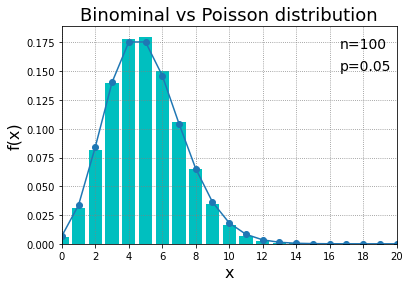

In [5]:
from scipy.stats import norm
from scipy.stats import binom
import matplotlib.ticker as ticker

# ----- you can set values below -----
n = 100      # 試行回数
p = 0.05     # 成功確率 valid range: [0, 1]
# ------------------------------------

# 二項分布
x = np.arange(0, n+1)  # 成功回数(list)
y_bi = binom.pmf(x, n, p)
#bi_dist[:10]
plt.bar(x, y_bi, color="c")  

# Poisson distribution
mu = n * p
y_p = poisson.pmf(x, mu)
plt.gca().get_xaxis().set_major_locator(ticker.MaxNLocator(integer=True))
plt.plot(x, y_p, marker='o')
plt.title('Poisson distribution pmf')
plt.grid(color='gray',linestyle=':');

plt.xlim(0, 20)
plt.title('Binominal vs Poisson distribution', fontsize=18)
plt.xlabel('x', fontsize=16)
plt.ylabel('f(x)', fontsize=16)
plt.text(0.83, 0.9, f"n={n}", fontsize=14, transform=plt.gca().transAxes)
plt.text(0.83, 0.8, f"p={p}", fontsize=14, transform=plt.gca().transAxes)
print(f'平均(=n*p): {mu} / 標準偏差: {np.sqrt(n*p*(1-p)):.3f}')

#### 問題4-3についてのコメント
+ $\mu=np$ を一定に保ったまま、$n \to \infty$ とした場合にPosson分布の結果に漸近
+ クラス人数が不明の場合でも、この仮定を前提とすれば近似的に計算できる、ということ。
+ 精度が必要な場合は、クラス人数の情報を得た上で二項分布を使用する。

欠席確率：0.05
2週連続無欠席確率@Binominal：0.005921
2週連続無欠席確率@Poisson  ：0.006738
[7.69449753e-02 2.02486777e-01 2.61101370e-01 2.19874838e-01
 1.35975229e-01 6.58406372e-02 2.59897252e-02 8.59810457e-03
 2.43235853e-03 5.97421394e-04 1.28917248e-04 2.46731575e-05
 4.22040852e-06 6.49293619e-07 9.03152779e-08]


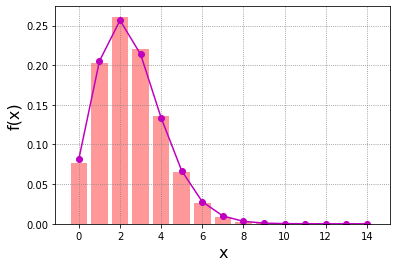

In [6]:
# ----- you can set values below -----
mu = 2.5
n = 50      # クラス人数
p = mu/n    # 欠席確率 valid range: [0, 1]
# ------------------------------------
print(f'欠席確率：{mu/n:.2f}')
x = np.arange(0, 15)  # 成功回数のリスト
y = binom.pmf(x,n,p)  # 二項分布の確率質量関数 (PMF)

plt.bar(x, y, color='r', alpha=0.4)
plt.xlabel('x', fontsize=16)
plt.ylabel('f(x)', fontsize=16)

# Poisson distribution
mu = n * p
y_p = poisson.pmf(x, mu)
plt.gca().get_xaxis().set_major_locator(ticker.MaxNLocator(integer=True))
plt.plot(x, y_p, 'mo-')
plt.grid(color='gray',linestyle=':');

# 2週連続無欠席確率
print(f'2週連続無欠席確率@Binominal：{y[0]**2:.4g}')
print(f'2週連続無欠席確率@Poisson  ：{y_p[0]**2:.4g}')
print(y)